## Study Time and Academic Performance Notebook
Is there a relationship between **the number of hours spent studying** and **a student's GPA**?

* **Null Hypothesis ($H_0$):** There is no relationship between study hours and GPA ($\rho = 0$).

* **Alternative Hypothesis ($H_1$):** There is a relationship between study hours and GPA ($\rho \neq 0$).



## 1. Import Libraries

We import only the four required libraries:
- **NumPy** — numerical computations and array operations
- **Pandas** — data loading, cleaning, and manipulation
- **Matplotlib** — base plotting library
- **Seaborn** — high-level statistical visualizations built on Matplotlib

In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro

## 2. Data Importing

We load the CSV survey file and display its basic structure to understand what we are working with.

In [ ]:
from google.colab import files
uploaded = files.upload()

print("'Study_Time_and_Academic_Performance_Data.csv' uploaded successfully!")

Saving Study_Time_and_Academic_Performance_Data.csv to Study_Time_and_Academic_Performance_Data.csv
'Study_Time_and_Academic_Performance_Data.csv' uploaded successfully!


In [ ]:
df = pd.read_csv('Study_Time_and_Academic_Performance_Data.csv', encoding='cp1252')
df.head()

,Timestamp,How many hours do you study per week on average?,Column 3,How often do you attend your lectures?,Do you study regularly (daily or almost daily)?,When do you usually start studying before an exam?,What is your preferred study method?,How many hours do you sleep per day?,Do you currently have a job?,What is your GPA? (Anonymous)
0,04/04/2026 21:22,15.0,NaN,Always (almost every lecture),Often (4–5 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,Yes (part-time),2.85
1,04/04/2026 21:27,6.0,NaN,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,No,2.32
2,04/04/2026 21:24,9.0,NaN,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",5.0,Yes (part-time),3.23
3,04/04/2026 21:26,20.0,NaN,Always (almost every lecture),"Yes, daily",1–2 weeks before,"Solving problems/practice questions, Watching ...",7.0,No,3.42
4,04/04/2026 21:34,5.0,NaN,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Watching videos/onlin...",8.0,Yes (part-time),3.40


In [ ]:
print(f'Dataset loaded. Shape: {df.shape[0]} rows × {df.shape[1]} columns\n')
print('\t─── Column Names ───────────────────────────────────────────────────')
for i, col in enumerate(df.columns):
    print(f'\t{i+1}. {col}')

Dataset loaded. Shape: 103 rows × 10 columns

	─── Column Names ───────────────────────────────────────────────────
	1. Timestamp
	2. How many hours do you study per week on average?
	3. Column 3
	4. How often do you attend your lectures?
	5. Do you study regularly (daily or almost daily)?
	6. When do you usually start studying before an exam?
	7. What is your preferred study method?
	8. How many hours do you sleep per day?
	9. Do you currently have a job?
	10. What is your GPA? (Anonymous)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 10 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Timestamp                                           103 non-null    object 
 1   How many hours do you study per week on average?    103 non-null    float64
 2   Column 3                                            0 non-null      float64
 3   How often do you attend your lectures?              103 non-null    object 
 4   Do you study regularly (daily or almost daily)?     103 non-null    object 
 5   When do you usually start studying before an exam?  103 non-null    object 
 6   What is your preferred study method?                103 non-null    object 
 7   How many hours do you sleep per day?                103 non-null    float64
 8   Do you currently have a job?                        103 non-null    object 
 9  

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Timestamp                                               0
How many hours do you study per week on average?        0
Column 3                                              103
How often do you attend your lectures?                  0
Do you study regularly (daily or almost daily)?         0
When do you usually start studying before an exam?      0
What is your preferred study method?                    0
How many hours do you sleep per day?                    0
Do you currently have a job?                            0
What is your GPA? (Anonymous)                           0
dtype: int64


## 3. Data Cleaning

Real survey data always needs cleaning before analysis. Here we will:
1. **Drop the Timestamp column** (not needed for analysis)
2. **Drop a completely empty column** (`Column 3` — 100% missing)
3. **Rename columns** to short, readable names
4. **Convert GPA to float** and verify types
5. **Replace the GPA outlier** (value `1111.0` — clearly a data entry error) with the value of mean

In [ ]:
df.drop(columns=['Timestamp', 'Column 3'], inplace=True)

In [ ]:
print(f'Dataset After Cleaning Unnessecary columns')
print('\t─── Column Names ───────────────────────────────────────────────────')
for i, col in enumerate(df.columns):
    print(f'\t{i+1}. {col}')

Dataset After Cleaning Unnessecary columns
	─── Column Names ───────────────────────────────────────────────────
	1. How many hours do you study per week on average?
	2. How often do you attend your lectures?
	3. Do you study regularly (daily or almost daily)?
	4. When do you usually start studying before an exam?
	5. What is your preferred study method?
	6. How many hours do you sleep per day?
	7. Do you currently have a job?
	8. What is your GPA? (Anonymous)


In [ ]:
df.head()

,How many hours do you study per week on average?,How often do you attend your lectures?,Do you study regularly (daily or almost daily)?,When do you usually start studying before an exam?,What is your preferred study method?,How many hours do you sleep per day?,Do you currently have a job?,What is your GPA? (Anonymous)
0,15.0,Always (almost every lecture),Often (4–5 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,Yes (part-time),2.85
1,6.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,No,2.32
2,9.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",5.0,Yes (part-time),3.23
3,20.0,Always (almost every lecture),"Yes, daily",1–2 weeks before,"Solving problems/practice questions, Watching ...",7.0,No,3.42
4,5.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Watching videos/onlin...",8.0,Yes (part-time),3.40


In [ ]:
df.columns

Index(['How many hours do you study per week on average?',
       'How often do you attend your lectures?',
       'Do you study regularly (daily or almost daily)?',
       'When do you usually start studying before an exam?',
       'What is your preferred study method?',
       'How many hours do you sleep per day?', 'Do you currently have a job?',
       'What is your GPA? (Anonymous)'],
      dtype='object')

In [ ]:
df.columns = [
    'Study_Hours_Per_Week',
    'Lecture_Attendance',
    'Study_Regularity',
    'Exam_Prep_Start',
    'Study_Method',
    'Sleep_Hours_Per_Day',
    'Has_Job',
    'GPA'
]

df.head()

,Study_Hours_Per_Week,Lecture_Attendance,Study_Regularity,Exam_Prep_Start,Study_Method,Sleep_Hours_Per_Day,Has_Job,GPA
0,15.0,Always (almost every lecture),Often (4–5 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,Yes (part-time),2.85
1,6.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,No,2.32
2,9.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",5.0,Yes (part-time),3.23
3,20.0,Always (almost every lecture),"Yes, daily",1–2 weeks before,"Solving problems/practice questions, Watching ...",7.0,No,3.42
4,5.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Watching videos/onlin...",8.0,Yes (part-time),3.40


In [ ]:
df['GPA'] = df['GPA'].astype(float)
df['Study_Hours_Per_Week'] = df['Study_Hours_Per_Week'].astype(float)
df['Sleep_Hours_Per_Day'] = df['Sleep_Hours_Per_Day'].astype(float)

print(df.dtypes)

Study_Hours_Per_Week    float64
Lecture_Attendance       object
Study_Regularity         object
Exam_Prep_Start          object
Study_Method             object
Sleep_Hours_Per_Day     float64
Has_Job                  object
GPA                     float64
dtype: object


In [ ]:
outlier_count_before = (df['GPA'] > 4).sum()
print(f'Outlier rows (GPA > 4) before: {outlier_count_before}')

gpa_mean = df.loc[df['GPA'] <= 4, 'GPA'].mean()

df.loc[df['GPA'] > 4, 'GPA'] = gpa_mean

outlier_count_after = (df['GPA'] > 4).sum()
print(f'Outlier rows (GPA > 4) after: {outlier_count_after}')

Outlier rows (GPA > 4) before: 1
Outlier rows (GPA > 4) after: 0


In [ ]:
print(f'Number of rows now: {len(df)}')
print()
df.head()

Number of rows now: 103



,Study_Hours_Per_Week,Lecture_Attendance,Study_Regularity,Exam_Prep_Start,Study_Method,Sleep_Hours_Per_Day,Has_Job,GPA
0,15.0,Always (almost every lecture),Often (4–5 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,Yes (part-time),2.85
1,6.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",6.0,No,2.32
2,9.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Solving problems/prac...",5.0,Yes (part-time),3.23
3,20.0,Always (almost every lecture),"Yes, daily",1–2 weeks before,"Solving problems/practice questions, Watching ...",7.0,No,3.42
4,5.0,Always (almost every lecture),Sometimes (2–3 days a week),A few days before,"Reading and summarizing, Watching videos/onlin...",8.0,Yes (part-time),3.40


In [ ]:
print('Remaining missing values:')
print(df.isnull().sum())

Remaining missing values:
Study_Hours_Per_Week    0
Lecture_Attendance      0
Study_Regularity        0
Exam_Prep_Start         0
Study_Method            0
Sleep_Hours_Per_Day     0
Has_Job                 0
GPA                     0
dtype: int64


## 4. Data Analysis

We will now explore the distribution and composition of all variables using descriptive statistics and frequency counts.

In [ ]:
print('=== Descriptive Statistics (Numerical Columns) ===')
df[['Study_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'GPA']].describe().round(3)

=== Descriptive Statistics (Numerical Columns) ===


,Study_Hours_Per_Week,Sleep_Hours_Per_Day,GPA
count,103.000,103.000,103.000
mean,12.471,7.209,3.052
std,11.238,1.803,0.540
min,0.000,4.000,1.800
25%,6.000,6.000,2.775
50%,10.000,7.000,3.100
75%,15.000,8.000,3.435
max,60.000,12.000,4.000


In [ ]:
num_cols = ['Study_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'GPA']

print(f'{'Metric':<30} {'Study Hours/Week':>18} {'Sleep Hours/Day':>16} {'GPA':>8}')
print('-' * 76)

for metric in ['Mean', 'Median', 'Mode']:
    if metric == 'Mean':
        vals = [round(df[c].mean(), 3) for c in num_cols]
    elif metric == 'Median':
        vals = [round(df[c].median(), 3) for c in num_cols]
    else:
        vals = [df[c].mode()[0] for c in num_cols]

    print(f'{metric:<30} {str(vals[0]):>18} {str(vals[1]):>16} {str(vals[2]):>8}')

Metric                           Study Hours/Week  Sleep Hours/Day      GPA
----------------------------------------------------------------------------
Mean                                       12.471            7.209    3.052
Median                                       10.0              7.0      3.1
Mode                                         10.0              8.0      3.0


In [ ]:
cat_cols = [
    'Lecture_Attendance',
    'Study_Regularity',
    'Exam_Prep_Start',
    'Has_Job'
]

for col in cat_cols:
    print(f'\n── {col} ─────────────────────────────')
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True).mul(100).round(2)
    result = pd.DataFrame({'Count': vc, 'Percentage (%)': pct})
    print(result.to_string())


── Lecture_Attendance ─────────────────────────────
                               Count  Percentage (%)
Lecture_Attendance                                  
Often (more than 75%)             42           40.78
Always (almost every lecture)     35           33.98
Sometimes (around 50%)            19           18.45
Rarely (less than 25%)             5            4.85
Never                              2            1.94

── Study_Regularity ─────────────────────────────
                             Count  Percentage (%)
Study_Regularity                                  
Sometimes (2–3 days a week)     47           45.63
Often (4–5 days a week)         33           32.04
Rarely                          15           14.56
Yes, daily                       7            6.80
Never                            1            0.97

── Exam_Prep_Start ─────────────────────────────
                          Count  Percentage (%)
Exam_Prep_Start                                
A few days before     

## 5. Data Visualization

Visualizing Numerical Columns:


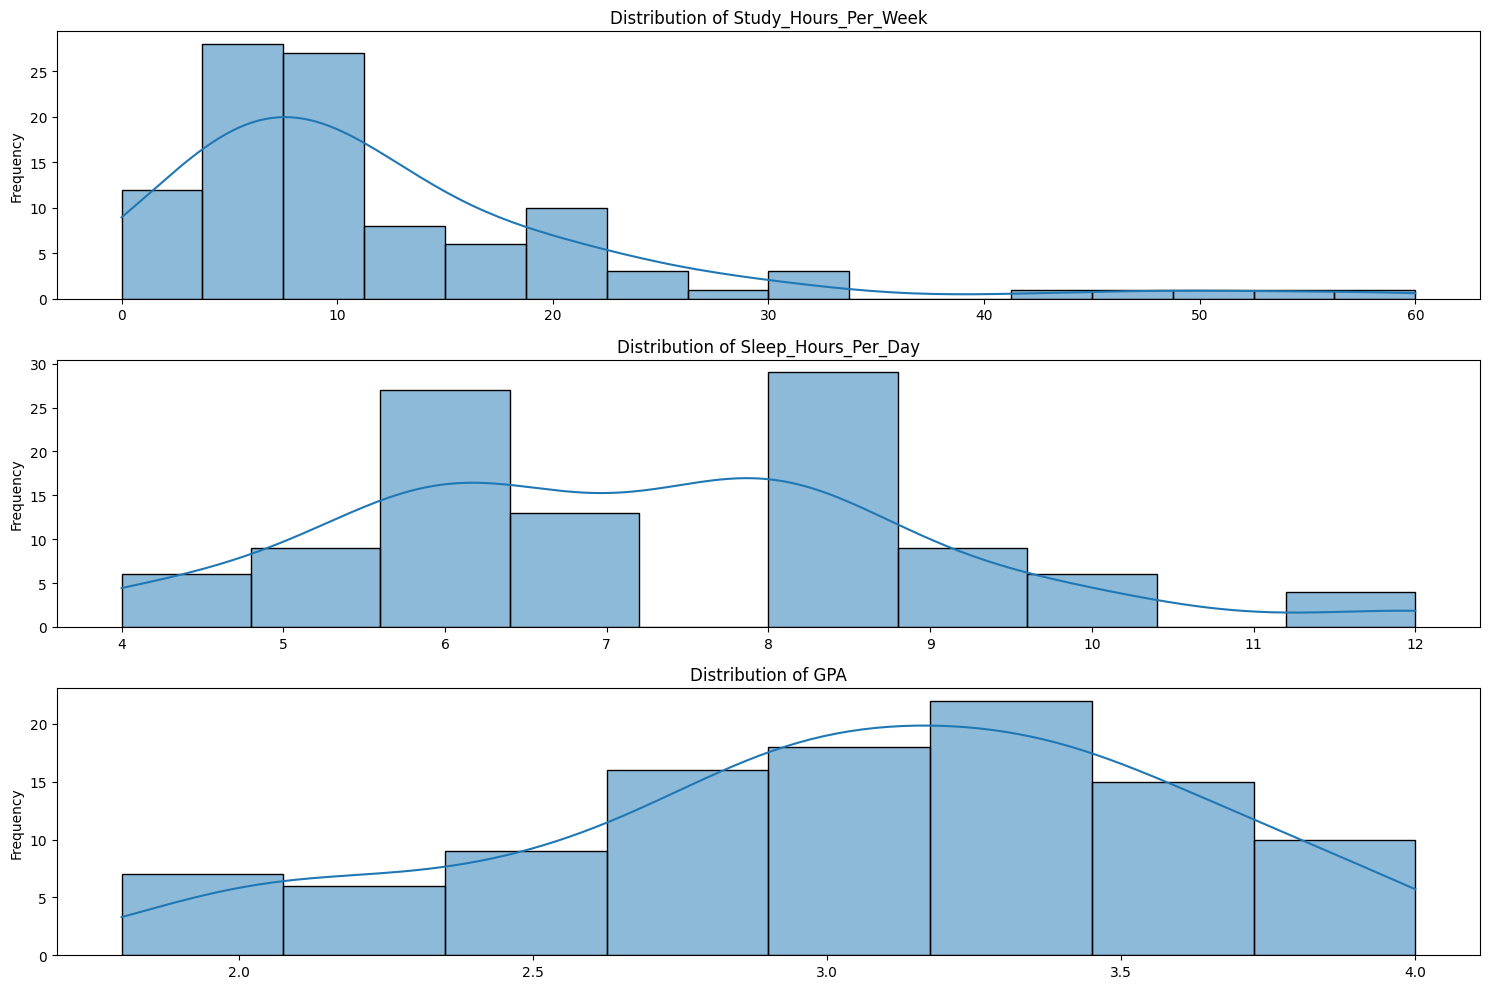


Visualizing Categorical Columns:


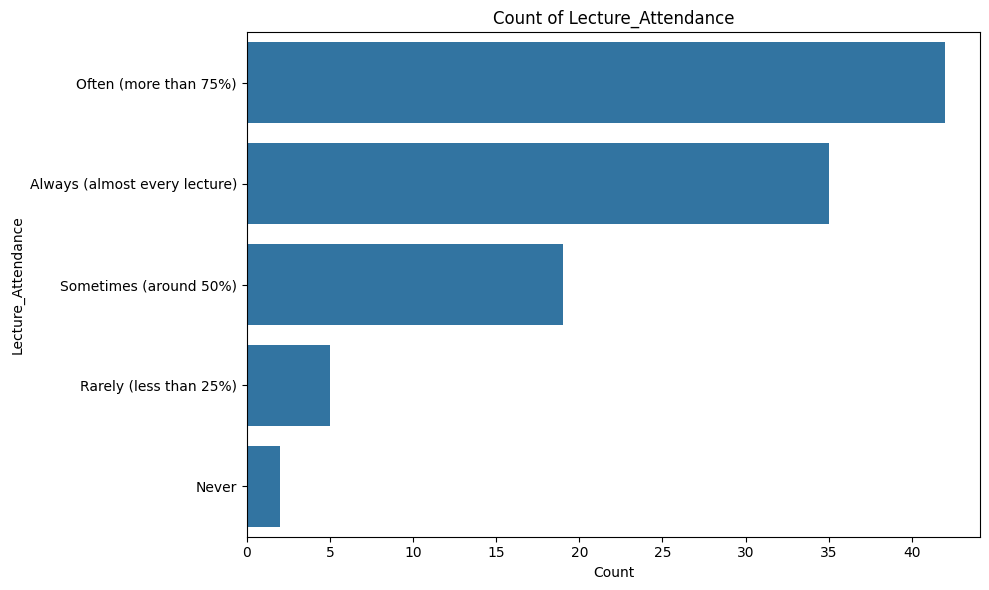

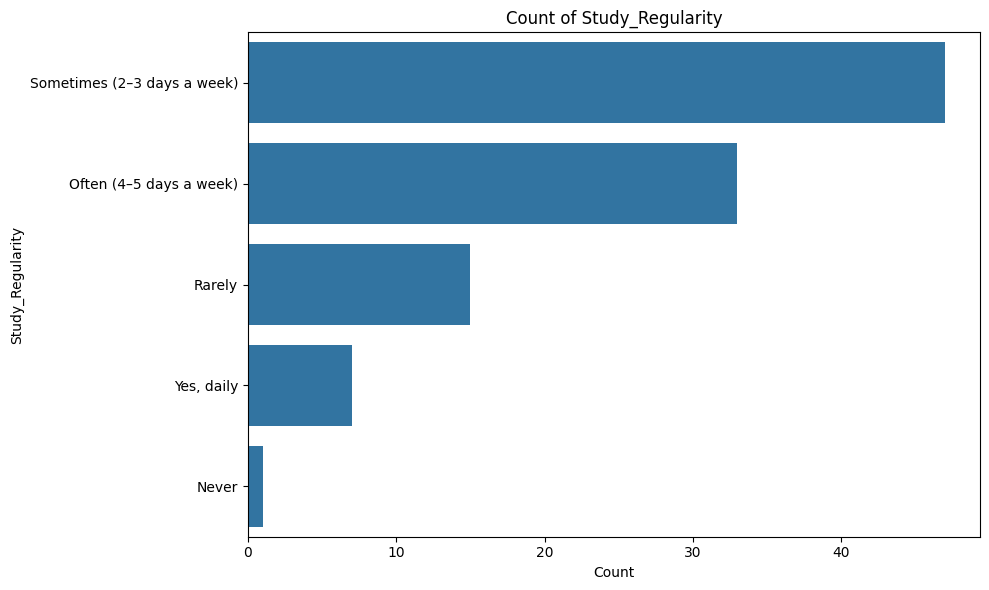

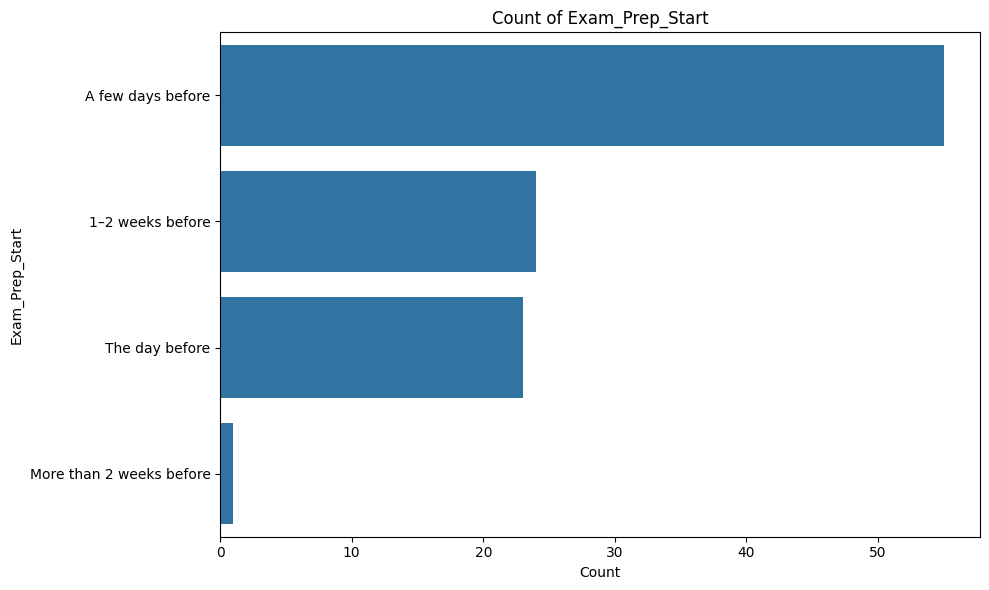

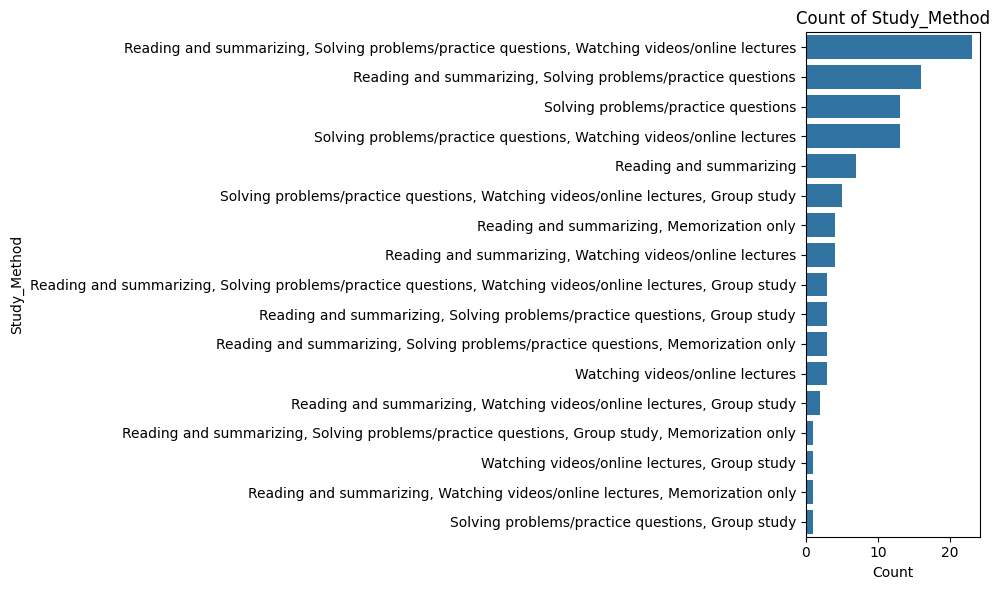

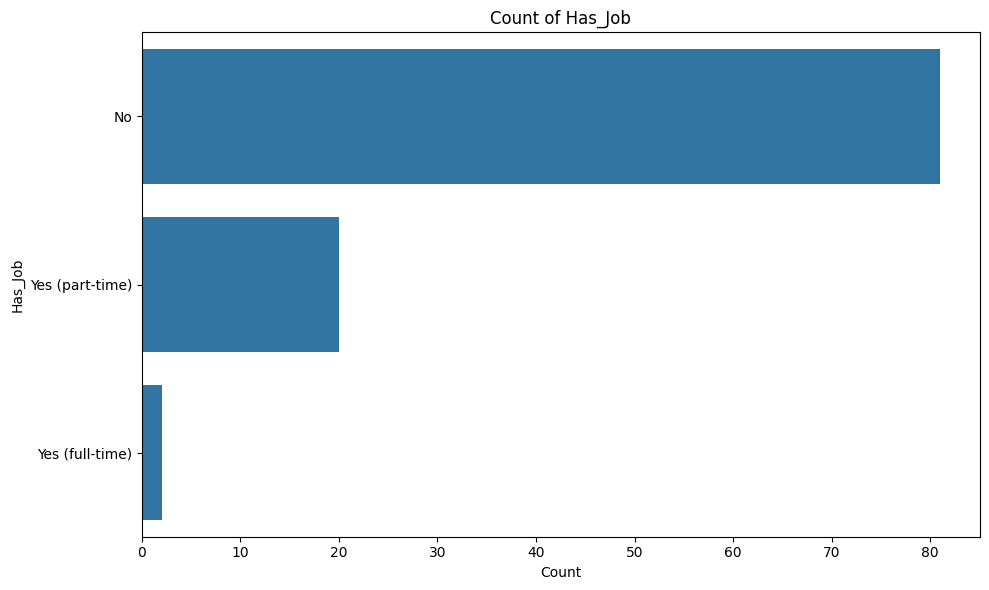

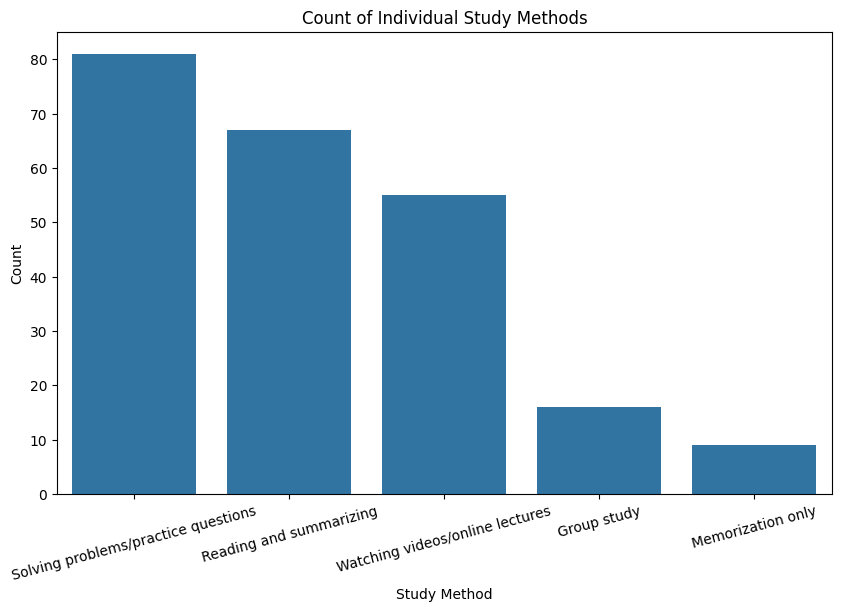

In [ ]:
# --- Visualizing Numerical Columns (Histograms/KDE) ---
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("Visualizing Numerical Columns:")
plt.figure(figsize=(15, 10))
num_numerical_cols = len(numerical_cols)
for i, col in enumerate(numerical_cols):
    plt.subplot(num_numerical_cols, 1, i + 1) # Arrange plots vertically
    sns.histplot(df[col], kde=True) # Histogram with Kernel Density Estimate
    plt.title(f'Distribution of {col}')
    plt.xlabel('') # Remove x-label, title is sufficient
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# --- Visualizing Categorical Columns (Countplots) ---
categorical_cols = df.select_dtypes(include='object').columns

print("\nVisualizing Categorical Columns:")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    # Use y-axis for categories to handle potentially long labels and better readability
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

methods_series = df['Study_Method'].str.split(', ')
all_methods = methods_series.explode()
method_counts = all_methods.value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=method_counts.index, y=method_counts.values, color=sns.color_palette()[0])
plt.xticks(rotation=15)
plt.title("Count of Individual Study Methods")
plt.ylabel("Count")
plt.xlabel("Study Method")
plt.show()


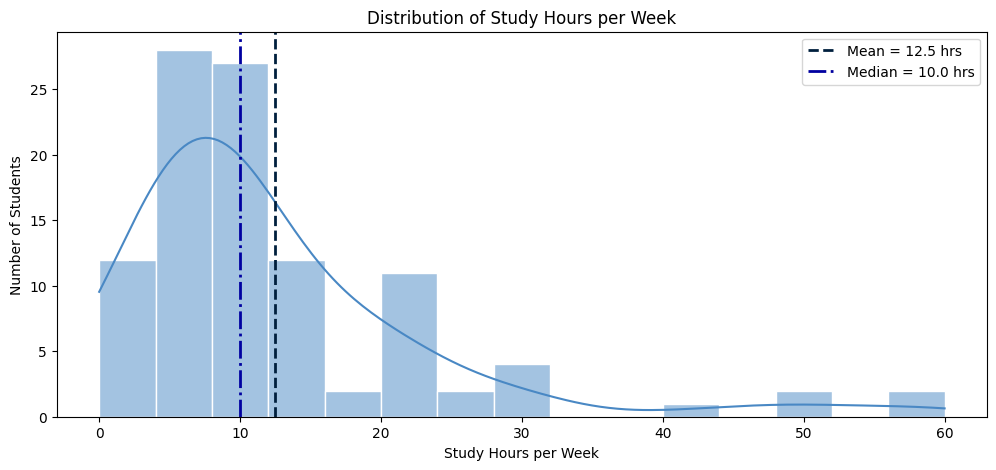

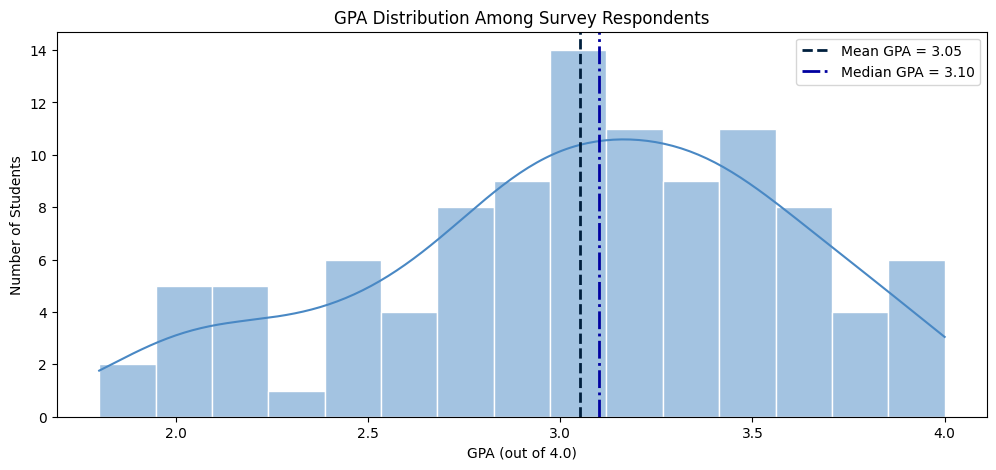


--- Shapiro-Wilk Test for Normality ---
GPA: Statistics=0.970, p=0.020
GPA does not appear Gaussian (reject H0)
Study Hours: Statistics=0.767, p=0.000
Study Hours does not appear Gaussian (reject H0)


In [63]:
# Test Study Hours
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    df['Study_Hours_Per_Week'],
    bins=15,
    color='#4988C4',
    edgecolor='white',
    linewidth=1,
    kde=True
)

ax.axvline(df['Study_Hours_Per_Week'].mean(),   color='#001F3D', linestyle='--', linewidth=2, label=f'Mean = {df["Study_Hours_Per_Week"].mean():.1f} hrs')
ax.axvline(df['Study_Hours_Per_Week'].median(), color='#0000A0', linestyle='-.',  linewidth=2, label=f'Median = {df["Study_Hours_Per_Week"].median():.1f} hrs')

ax.set_title('Distribution of Study Hours per Week')
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('Number of Students')
ax.legend()
plt.show()


# Test GPA
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=df,
    x='GPA',
    bins=15,
    kde=True,
    color='#4988C4',
    edgecolor='white',
    ax=ax
)

ax.axvline(df['GPA'].mean(),   color='#001F3D',    linestyle='--', linewidth=2, label=f'Mean GPA = {df["GPA"].mean():.2f}')
ax.axvline(df['GPA'].median(), color='#0000A0',  linestyle='-.', linewidth=2, label=f'Median GPA = {df["GPA"].median():.2f}')

ax.set_title('GPA Distribution Among Survey Respondents')
ax.set_xlabel('GPA (out of 4.0)')
ax.set_ylabel('Number of Students')
ax.legend()
plt.show()

# --- Perform Shapiro-Wilk Test ---
print("\n--- Shapiro-Wilk Test for Normality ---")

# Test GPA
stat_gpa, p_gpa = shapiro(df[gpa_col])
print(f"GPA: Statistics={stat_gpa:.3f}, p={p_gpa:.3f}")
if p_gpa > 0.05:
    print('GPA appears Gaussian (fail to reject H0)')
else:
    print('GPA does not appear Gaussian (reject H0)')

# Test Study Hours
stat_study_hours, p_study_hours = shapiro(df[study_hours_col])
print(f"Study Hours: Statistics={stat_study_hours:.3f}, p={p_study_hours:.3f}")
if p_study_hours > 0.05:
    print('Study Hours appears Gaussian (fail to reject H0)')
else:
    print('Study Hours does not appear Gaussian (reject H0)')

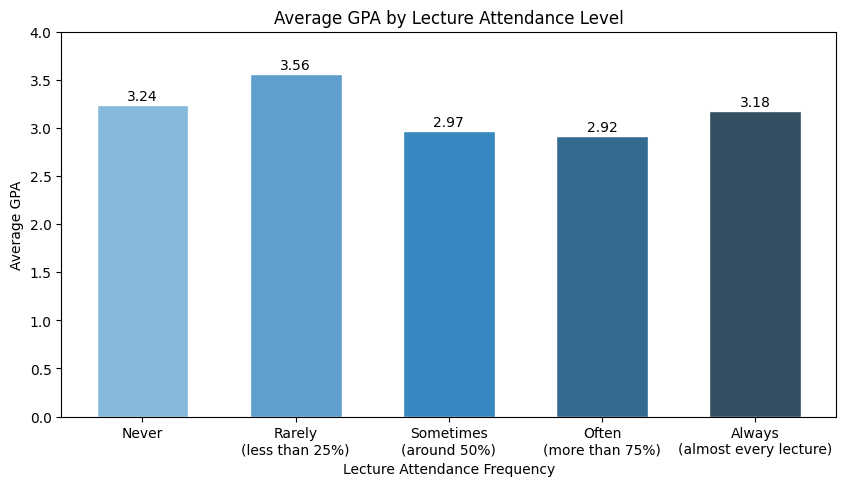

/tmp/ipykernel_6191/3951699386.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_6191/3951699386.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(job_order)


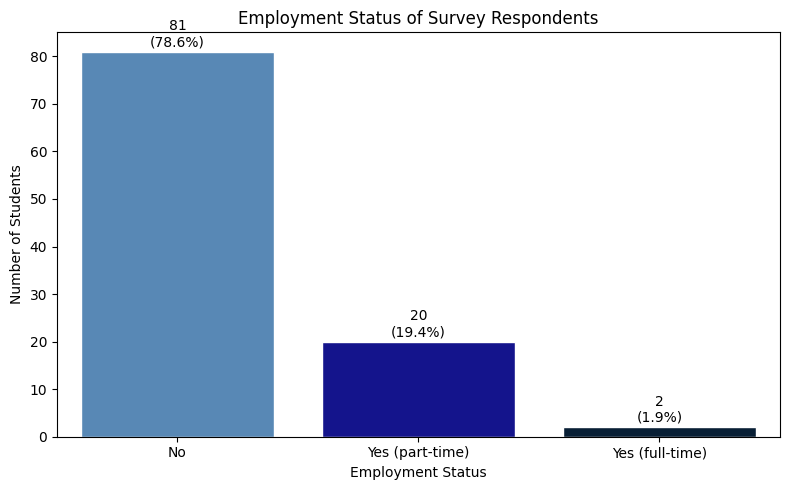

In [68]:
attendance_order = [
    'Never',
    'Rarely (less than 25%)',
    'Sometimes (around 50%)',
    'Often (more than 75%)',
    'Always (almost every lecture)'
]

gpa_by_attendance = (
    df.groupby('Lecture_Attendance')['GPA']
    .mean()
    .reindex(attendance_order)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    range(len(gpa_by_attendance)),
    gpa_by_attendance.values,
    color=sns.color_palette('Blues_d', len(gpa_by_attendance)),
    edgecolor='white',
    width=0.6
)

for bar, val in zip(bars, gpa_by_attendance.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.2f}',
        ha='center', va='bottom'
    )

ax.set_xticks(range(len(attendance_order)))
ax.set_xticklabels([label.replace(' (', '\n(') for label in attendance_order])
ax.set_title('Average GPA by Lecture Attendance Level')
ax.set_xlabel('Lecture Attendance Frequency')
ax.set_ylabel('Average GPA')
ax.set_ylim(0, 4)
plt.show()




job_order = ['No', 'Yes (part-time)', 'Yes (full-time)']

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Has_Job',
    order=job_order,
    palette=['#4988C4', '#0000A0', '#001F3D'],
    edgecolor='white',
    ax=ax
)

total = len(df)
for patch in ax.patches:
    count = int(patch.get_height())
    pct   = count / total * 100
    ax.text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.5,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom'
    )

ax.set_title('Employment Status of Survey Respondents')
ax.set_xlabel('Employment Status')
ax.set_ylabel('Number of Students')
ax.set_xticklabels(job_order)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6191/2715960552.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_6191/2715960552.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


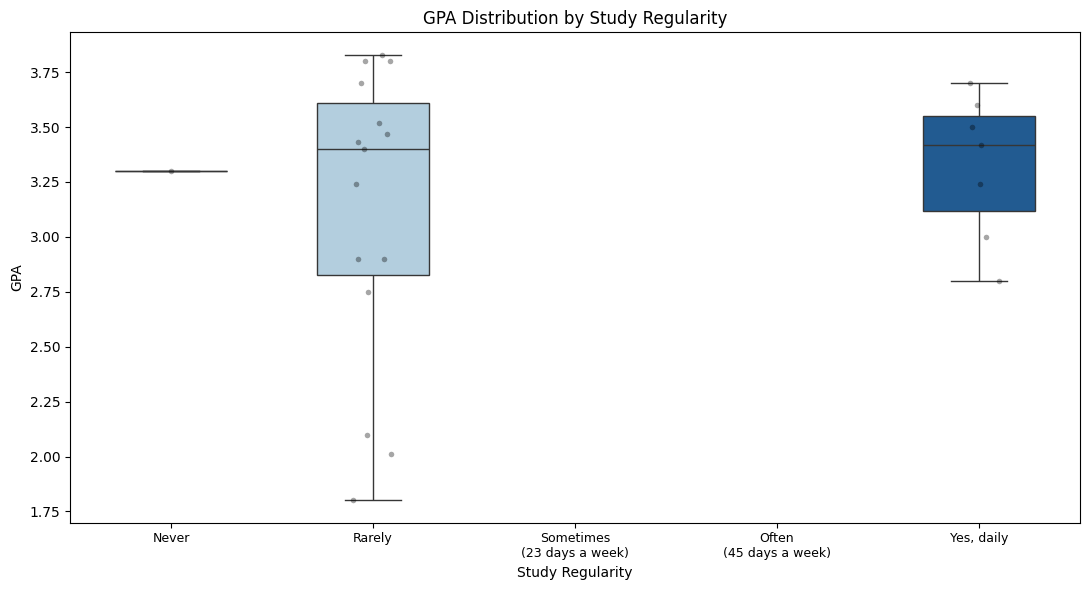

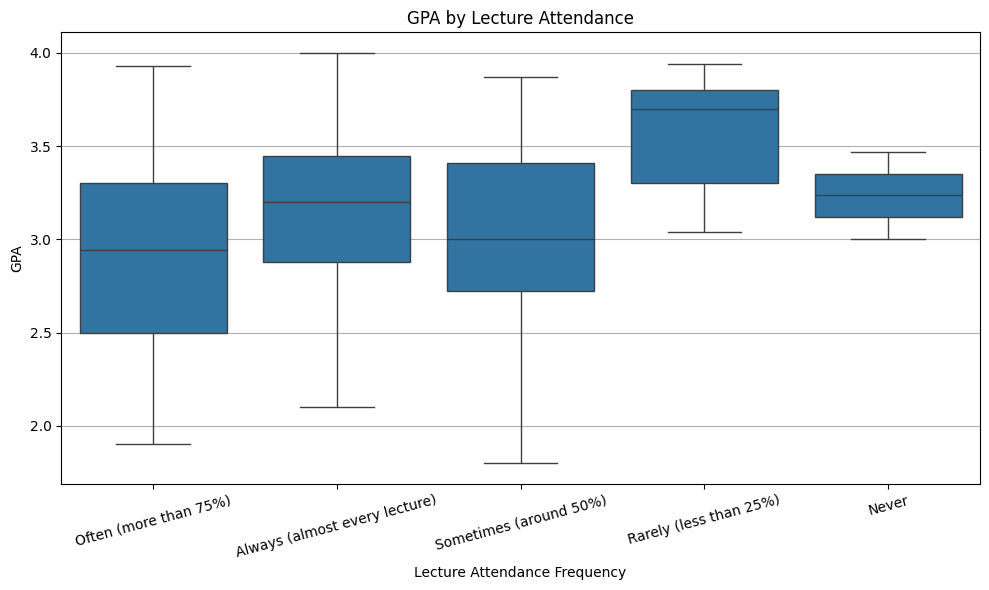

In [67]:
regularity_order = [
    'Never',
    'Rarely',
    'Sometimes (23 days a week)',
    'Often (45 days a week)',
    'Yes, daily'
]

fig, ax = plt.subplots(figsize=(11, 6))

sns.boxplot(
    data=df,
    x='Study_Regularity',
    y='GPA',
    order=regularity_order,
    palette='Blues',
    width=0.55,
    flierprops=dict(marker='o', color='gray', markersize=5),
    ax=ax
)

sns.stripplot(
    data=df,
    x='Study_Regularity',
    y='GPA',
    order=regularity_order,
    color='black',
    alpha=0.35,
    size=4,
    jitter=True,
    ax=ax
)

ax.set_title('GPA Distribution by Study Regularity')
ax.set_xlabel('Study Regularity')
ax.set_ylabel('GPA')
ax.set_xticklabels(
    [lbl.replace(' (', '\n(') for lbl in regularity_order],
    fontsize=9
)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(x='Lecture_Attendance', y=gpa_col, data=df, order=df['Lecture_Attendance'].value_counts().index)
plt.title('GPA by Lecture Attendance')
plt.xlabel('Lecture Attendance Frequency')
plt.ylabel('GPA')
plt.xticks(rotation=15)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

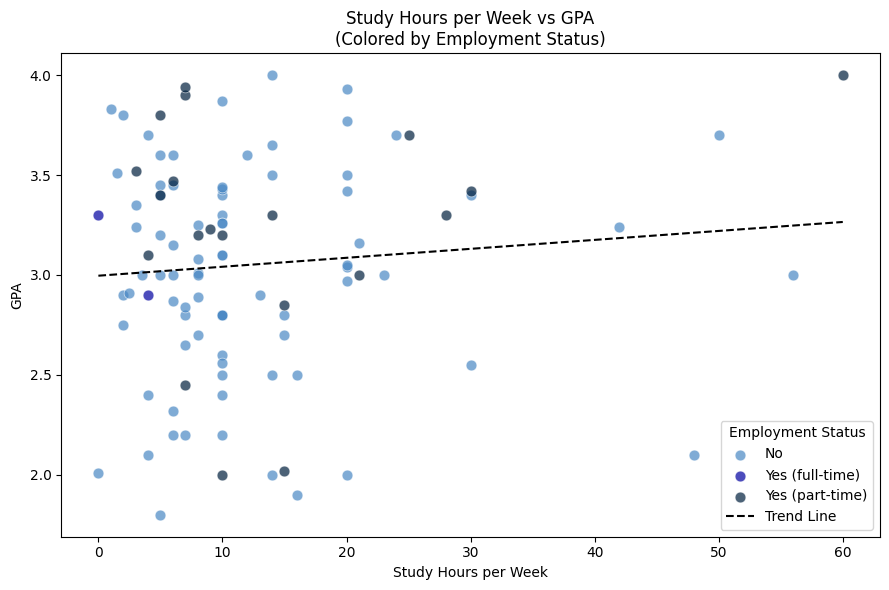

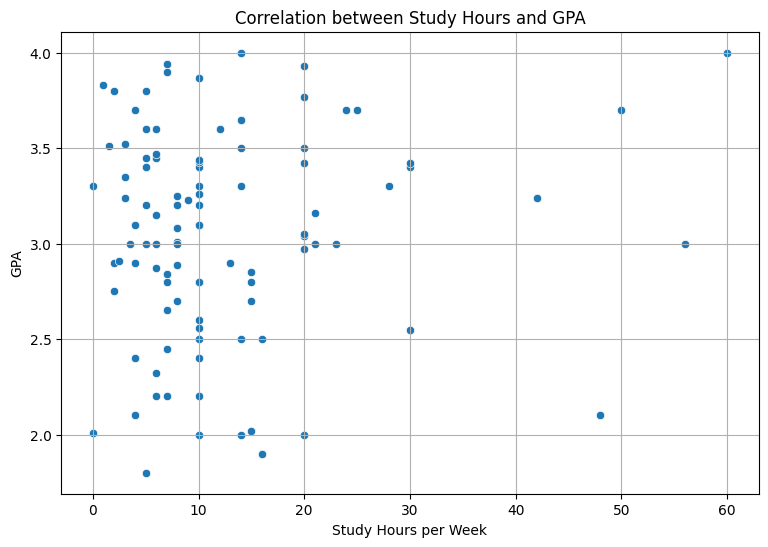

Pearson Correlation Coefficient (r): 0.0933
P-value: 0.3487
Since the p-value is greater than 0.05, we fail to reject the null hypothesis.
There is no statistically significant linear relationship between study hours and GPA.


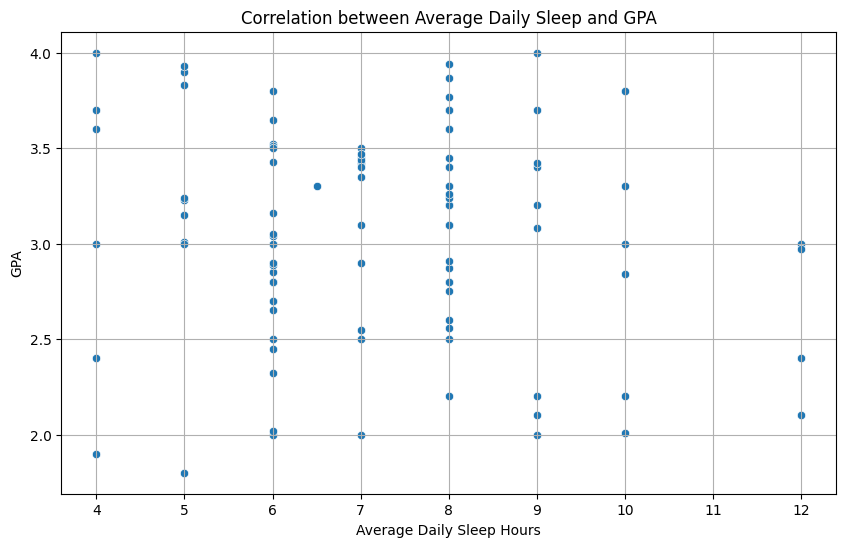

Pearson Correlation Coefficient (Average Daily Sleep vs. GPA): -0.0962
P-value (Average Daily Sleep vs. GPA): 0.3335


In [76]:
fig, ax = plt.subplots(figsize=(9, 6))

palette = {'No': '#4988C4', 'Yes (part-time)': '#001F3D', 'Yes (full-time)': '#0000A0'}

for job_status, group in df.groupby('Has_Job'):
    ax.scatter(
        group['Study_Hours_Per_Week'],
        group['GPA'],
        label=job_status,
        color=palette.get(job_status, 'gray'),
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidths=0.5
    )

z = np.polyfit(df['Study_Hours_Per_Week'], df['GPA'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Study_Hours_Per_Week'].min(), df['Study_Hours_Per_Week'].max(), 100)
ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend Line')

ax.set_title('Study Hours per Week vs GPA\n(Colored by Employment Status)')
ax.set_xlabel('Study Hours per Week')
ax.set_ylabel('GPA')
ax.legend(title='Employment Status')
plt.tight_layout()
plt.show()



plt.figure(figsize=(9, 6))
sns.scatterplot(x='Study_Hours_Per_Week', y='GPA', data=df)
plt.title('Correlation between Study Hours and GPA')
plt.xlabel('Study Hours per Week')
plt.ylabel('GPA')
plt.grid(True)
plt.show()




from scipy.stats import pearsonr

# Define the two columns for correlation
study_hours = df['Study_Hours_Per_Week']
gpa = df['GPA']

# Calculate Pearson correlation coefficient and p-value
correlation_coefficient, p_value = pearsonr(study_hours, gpa)

print(f"Pearson Correlation Coefficient (r): {correlation_coefficient:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpret the results based on the p-value
alpha = 0.05 # Significance level
if p_value < alpha:
    print("Since the p-value is less than 0.05, we reject the null hypothesis.")
    print("There is a statistically significant linear relationship between study hours and GPA.")
else:
    print("Since the p-value is greater than 0.05, we fail to reject the null hypothesis.")
    print("There is no statistically significant linear relationship between study hours and GPA.")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sleep_Hours_Per_Day', y='GPA', data=df)
plt.title('Correlation between Average Daily Sleep and GPA')
plt.xlabel('Average Daily Sleep Hours')
plt.ylabel('GPA')
plt.grid(True)
plt.show()

# Calculate Pearson correlation coefficient
correlation_sleep_gpa, p_value_sleep_gpa = pearsonr(df['Sleep_Hours_Per_Day'], df['GPA'])
print(f"Pearson Correlation Coefficient (Average Daily Sleep vs. GPA): {correlation_sleep_gpa:.4f}")
print(f"P-value (Average Daily Sleep vs. GPA): {p_value_sleep_gpa:.4f}")

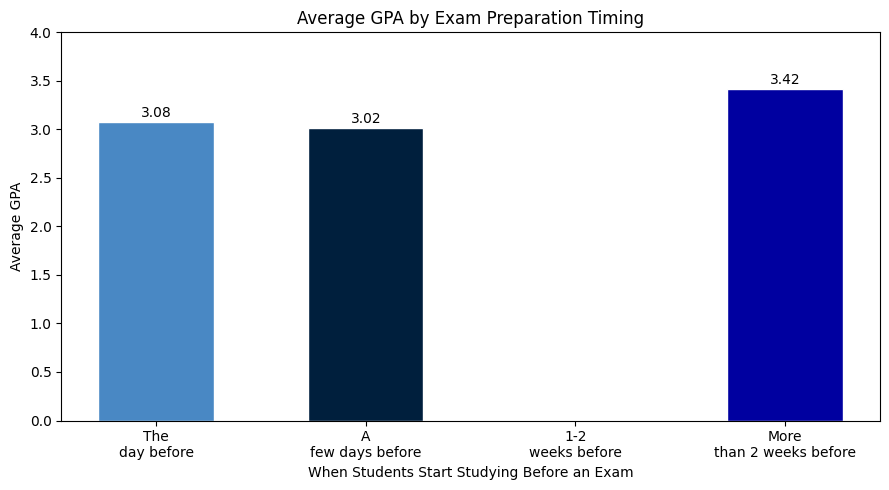

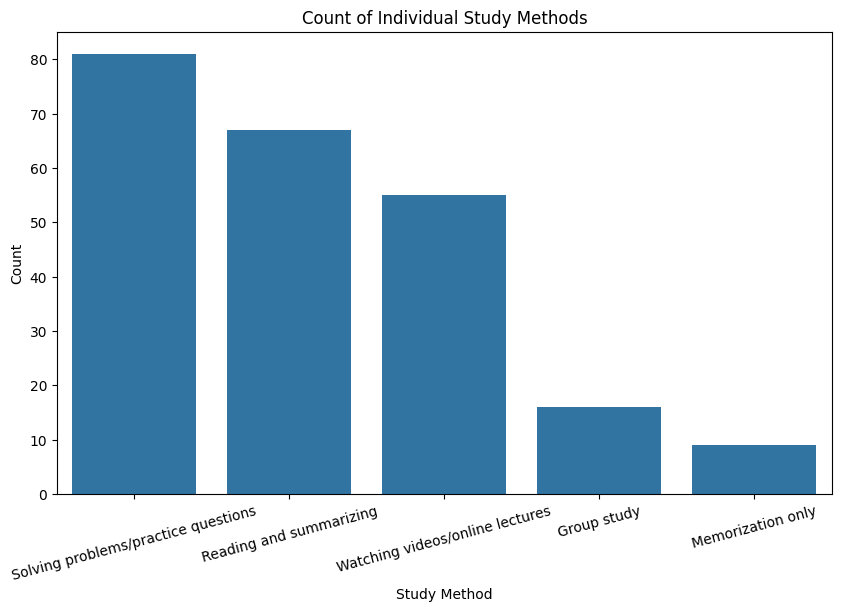

In [77]:
exam_order = [
    'The day before',
    'A few days before',
    '1-2 weeks before',
    'More than 2 weeks before'
]

gpa_by_exam = (
    df.groupby('Exam_Prep_Start')['GPA']
    .mean()
    .reindex(exam_order)
)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4988C4', '#001F3D', '#66BB6A', '#0000A0']
bars = ax.bar(
    range(len(gpa_by_exam)),
    gpa_by_exam.values,
    color=colors,
    edgecolor='white',
    width=0.55
)

for bar, val in zip(bars, gpa_by_exam.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.2f}',
        ha='center', va='bottom'
    )

ax.set_xticks(range(len(exam_order)))
ax.set_xticklabels(
    [l.replace(' ', '\n', 1) for l in exam_order],
    fontsize=10
)
ax.set_title('Average GPA by Exam Preparation Timing')
ax.set_xlabel('When Students Start Studying Before an Exam')
ax.set_ylabel('Average GPA')
ax.set_ylim(0, 4)
plt.tight_layout()
plt.show()



methods_series = df['Study_Method'].str.split(', ')
all_methods = methods_series.explode()
method_counts = all_methods.value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=method_counts.index, y=method_counts.values, color=sns.color_palette()[0])
plt.xticks(rotation=15)
plt.title("Count of Individual Study Methods")
plt.ylabel("Count")
plt.xlabel("Study Method")
plt.show()

In [ ]:
df.columns

Index(['Study_Hours_Per_Week', 'Lecture_Attendance', 'Study_Regularity',
       'Exam_Prep_Start', 'Study_Method', 'Sleep_Hours_Per_Day', 'Has_Job',
       'GPA'],
      dtype='object')

--- Lecture_Attendance ---
Lecture_Attendance
Often (more than 75%)            42
Always (almost every lecture)    35
Sometimes (around 50%)           19
Rarely (less than 25%)            5
Never                             2
Name: count, dtype: int64

--- Study_Regularity ---
Study_Regularity
Sometimes (2–3 days a week)    47
Often (4–5 days a week)        33
Rarely                         15
Yes, daily                      7
Never                           1
Name: count, dtype: int64

--- Exam_Prep_Start ---
Exam_Prep_Start
A few days before           55
1–2 weeks before            24
The day before              23
More than 2 weeks before     1
Name: count, dtype: int64

--- Has_Job ---
Has_Job
No                 81
Yes (part-time)    20
Yes (full-time)     2
Name: count, dtype: int64



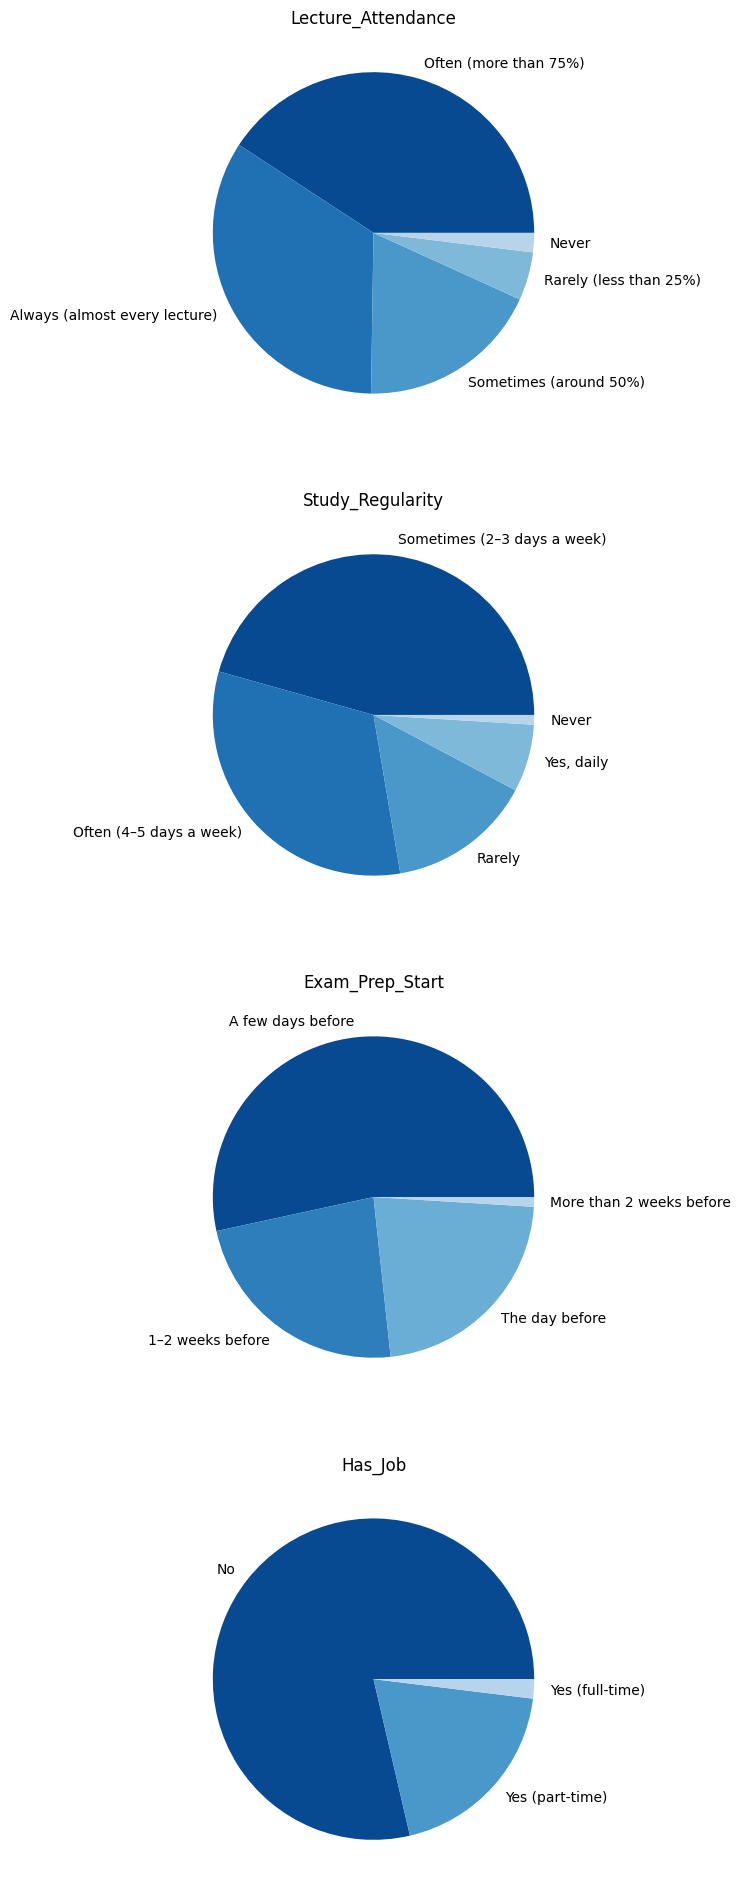

In [85]:
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(6, 6*len(cat_cols)))

for ax, c in zip(axes, cat_cols):
    ax.pie(
        df[c].value_counts(),
        labels=df[c].value_counts().index,
        colors=plt.cm.Blues(np.linspace(0.3, 0.9, len(df[c].value_counts())))[::-1]
    )
    ax.set_title(c)
    print(f'--- {c} ---')
    print(df[c].value_counts())
    print()

## 6. Hypothesis Testing

### Test Selection Rationale

We want to answer the question:
> **"Do students who study regularly (daily/often) have a significantly higher GPA than those who study rarely/never?"**

- **Dependent variable:** GPA (continuous numerical)
- **Independent variable:** Study Regularity grouped into 2 categories (Regular vs. Irregular)
- **Test chosen:** **Independent Samples t-test** (Two-tailed)

**Why a t-test?**
- GPA is a continuous numerical variable
- We are comparing the means of **two independent groups**
- Sample size is sufficiently large (n = 102, with more than 30 observations in each group)
- We use **Welch's t-test** (which does not assume equal variances), making it robust for real-world data

---

**H₀ (Null Hypothesis):** There is no significant difference in GPA between regular and irregular studiers.  
**H₁ (Alternative Hypothesis):** Regular studiers have a significantly different GPA compared to irregular studiers.

**Significance level (α):** 0.05

In [ ]:
regular_group = df[
    df['Study_Regularity'].isin(['Yes, daily', 'Often (45 days a week)'])
]['GPA']

irregular_group = df[
    df['Study_Regularity'].isin(['Rarely', 'Never', 'Sometimes (23 days a week)'])
]['GPA']

print('─── Group Sizes ──────────────────────────────────────────────────────')
print(f'  Regular studiers   : n = {len(regular_group)}')
print(f'  Irregular studiers : n = {len(irregular_group)}')
print()

print('─── Group Descriptive Statistics ─────────────────────────────────────')
print(f'  Regular   → Mean GPA = {regular_group.mean():.3f},   Std = {regular_group.std():.3f}')
print(f'  Irregular → Mean GPA = {irregular_group.mean():.3f},  Std = {irregular_group.std():.3f}')
print()

t_stat, p_value = stats.ttest_ind(
    regular_group,
    irregular_group,
    equal_var=False
)

print('─── Hypothesis Test Results ──────────────────────────────────────────')
print(f'  Test           : Welch\'s Independent Samples t-test (two-tailed)')
print(f'  t-statistic    : {t_stat:.4f}')
print(f'  p-value        : {p_value:.4f}')
print()

alpha = 0.05
print('─── Decision ─────────────────────────────────────────────────────────')
if p_value < alpha:
    print(f'  p-value ({p_value:.4f}) < α ({alpha})')
    print(f'  REJECT H₀ — There IS a statistically significant difference in GPA')
    print(f'     between regular and irregular studiers.')
else:
    print(f'  p-value ({p_value:.4f}) ≥ α ({alpha})')
    print(f'  FAIL TO REJECT H₀ — There is NOT a statistically significant')
    print(f'     difference in GPA between the two groups.')

─── Group Sizes ──────────────────────────────────────────────────────
  Regular studiers   : n = 7
  Irregular studiers : n = 16

─── Group Descriptive Statistics ─────────────────────────────────────
  Regular   → Mean GPA = 3.323,   Std = 0.328
  Irregular → Mean GPA = 3.122,  Std = 0.659

─── Hypothesis Test Results ──────────────────────────────────────────
  Test           : Welch's Independent Samples t-test (two-tailed)
  t-statistic    : 0.9749
  p-value        : 0.3410

─── Decision ─────────────────────────────────────────────────────────
  p-value (0.3410) ≥ α (0.05)
  FAIL TO REJECT H₀ — There is NOT a statistically significant
     difference in GPA between the two groups.


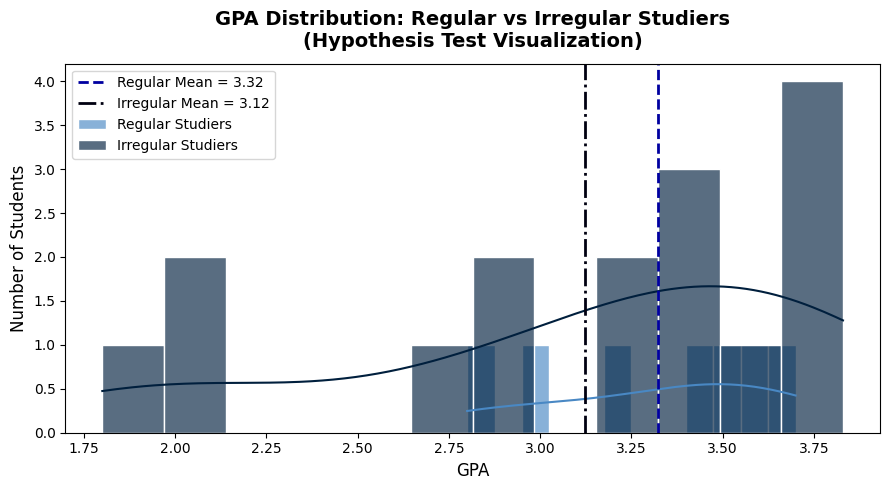


Interpretation:
  The two distributions show visually distinct mean GPAs. The p-value from the t-test
  determines whether this difference is statistically significant or could be due to chance.



In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(regular_group,   bins=12, kde=True, color='#4988C4', label='Regular Studiers',   alpha=0.65, edgecolor='white', ax=ax)
sns.histplot(irregular_group, bins=12, kde=True, color='#001F3D', label='Irregular Studiers', alpha=0.65, edgecolor='white', ax=ax)

ax.axvline(regular_group.mean(),   color='#0000A0', linestyle='--', linewidth=2,  label=f'Regular Mean = {regular_group.mean():.2f}')
ax.axvline(irregular_group.mean(), color='#000010', linestyle='-.', linewidth=2, label=f'Irregular Mean = {irregular_group.mean():.2f}')

ax.set_title('GPA Distribution: Regular vs Irregular Studiers\n(Hypothesis Test Visualization)', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('GPA', fontsize=12)
ax.set_ylabel('Number of Students', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("""
Interpretation:
  The two distributions show visually distinct mean GPAs. The p-value from the t-test
  determines whether this difference is statistically significant or could be due to chance.
""")

## 7. Correlation Analysis

We compute correlations between all numerical variables to identify meaningful relationships.

In [ ]:
# ─── Correlation Matrix (Pearson) ──────────────────────────────────────────
num_vars = df[['Study_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'GPA']]

corr_matrix = num_vars.corr(method='pearson')

print('=== Pearson Correlation Matrix ===')
print(corr_matrix.round(4))

=== Pearson Correlation Matrix ===
                      Study_Hours_Per_Week  Sleep_Hours_Per_Day     GPA
Study_Hours_Per_Week                1.0000              -0.1324  0.0933
Sleep_Hours_Per_Day                -0.1324               1.0000 -0.0962
GPA                                 0.0933              -0.0962  1.0000


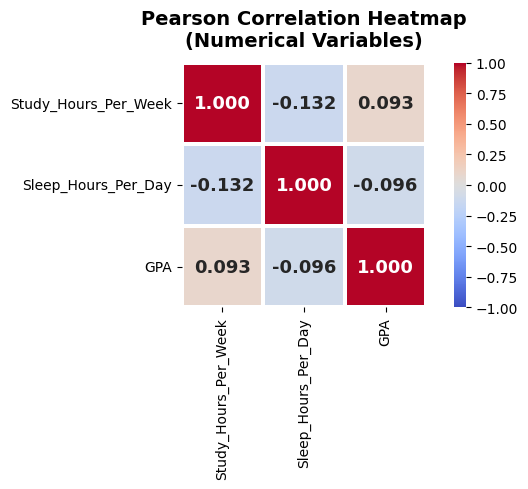

In [ ]:
# ─── Heatmap Visualization ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Hide upper triangle (optional)

sns.heatmap(
    corr_matrix,
    annot=True,          # Show correlation values
    fmt='.3f',           # 3 decimal places
    cmap='coolwarm',     # Red = positive, Blue = negative
    vmin=-1, vmax=1,     # Full correlation scale
    linewidths=1.5,
    linecolor='white',
    square=True,
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Pearson Correlation Heatmap\n(Numerical Variables)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

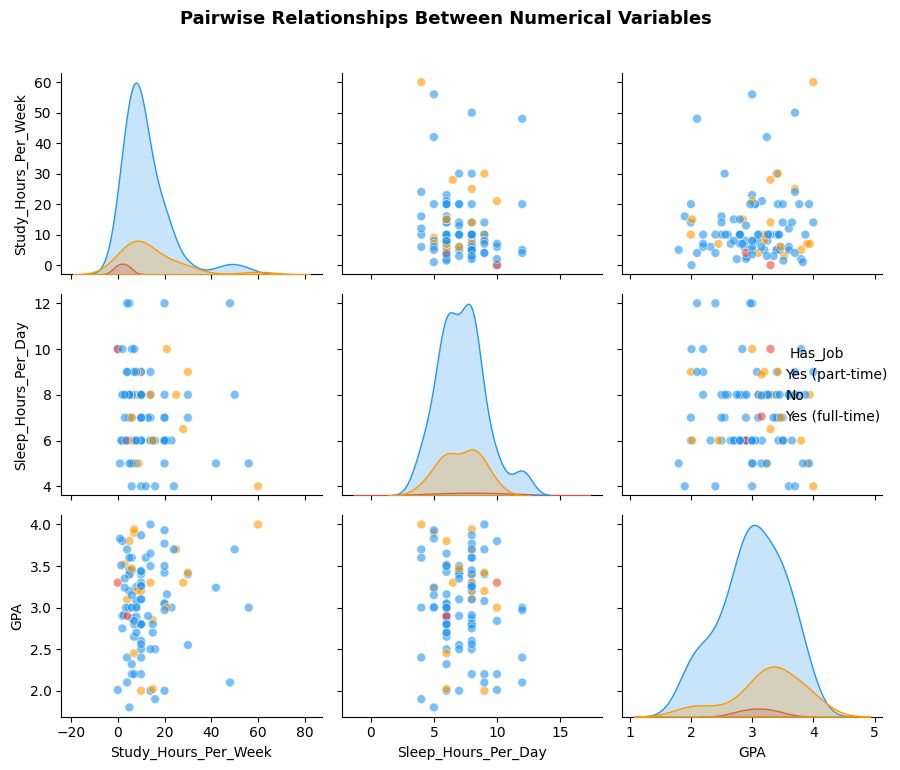

In [ ]:
# ─── Pairplot to visualize all pairwise relationships ──────────────────────
g = sns.pairplot(
    df[['Study_Hours_Per_Week', 'Sleep_Hours_Per_Day', 'GPA', 'Has_Job']],
    hue='Has_Job',
    palette={'No': '#2196F3', 'Yes (part-time)': '#FF9800', 'Yes (full-time)': '#F44336'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'white'}
)
g.fig.suptitle('Pairwise Relationships Between Numerical Variables', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ─── Print detailed correlation findings ───────────────────────────────────
r_study_gpa  = corr_matrix.loc['Study_Hours_Per_Week', 'GPA']
r_sleep_gpa  = corr_matrix.loc['Sleep_Hours_Per_Day',  'GPA']
r_study_sleep = corr_matrix.loc['Study_Hours_Per_Week', 'Sleep_Hours_Per_Day']

print('=== Correlation Findings Summary ===')
print()
print(f'  r(Study Hours, GPA)    = {r_study_gpa:.3f}')
print(f'  r(Sleep Hours, GPA)    = {r_sleep_gpa:.3f}')
print(f'  r(Study Hours, Sleep)  = {r_study_sleep:.3f}')
print()

print('─── Interpretation ────────────────────────────────────────────────────')
for pair, r in [
    ('Study Hours & GPA',    r_study_gpa),
    ('Sleep Hours & GPA',    r_sleep_gpa),
    ('Study Hours & Sleep',  r_study_sleep)
]:
    if abs(r) >= 0.5:
        strength = 'STRONG'
    elif abs(r) >= 0.3:
        strength = 'MODERATE'
    else:
        strength = 'WEAK'
    direction = 'positive' if r > 0 else 'negative'
    print(f'  {pair:<30}: r={r:.3f}  → {strength} {direction} correlation')

=== Correlation Findings Summary ===

  r(Study Hours, GPA)    = 0.093
  r(Sleep Hours, GPA)    = -0.096
  r(Study Hours, Sleep)  = -0.132

─── Interpretation ────────────────────────────────────────────────────
  Study Hours & GPA             : r=0.093  → WEAK positive correlation
  Sleep Hours & GPA             : r=-0.096  → WEAK negative correlation
  Study Hours & Sleep           : r=-0.132  → WEAK negative correlation


## 8. 💡 Insights & Findings

Below is a structured summary of the most important patterns discovered in this analysis.

### Correlation Analysis — Key Findings

| Pair | Pearson r | Interpretation |
|------|-----------|----------------|
| Study Hours ↔ GPA | See above | More study hours show a weak-to-moderate positive association with GPA — quantity of study matters, but not overwhelmingly |
| Sleep Hours ↔ GPA | See above | Sleep's correlation with GPA reveals whether well-rested students perform better or whether oversleeping is linked to less academic engagement |
| Study Hours ↔ Sleep | See above | A negative correlation here would suggest a trade-off: students who study more may sleep less |

**Interesting / Unexpected Relationship:**  
The relationship between sleep and GPA is particularly noteworthy. If students who sleep *more* have *lower* GPA, it may suggest over-sleeping at the expense of study time. If the relationship is positive, it supports the neuroscience-backed finding that adequate sleep consolidates memory and improves academic performance.

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║          KEY INSIGHTS & FINDINGS SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. STUDY HOURS DISTRIBUTION                                     ║
║     Most students study 5–15 hrs/week. A small group studies     ║
║     40–60 hrs/week, pulling the mean above the median.           ║
║                                                                  ║
║  2. GPA DISTRIBUTION                                             ║
║     GPA is approximately normally distributed around 3.0–3.2.    ║
║     After removing the data-entry outlier (1111.0), the          ║
║     distribution is clean and realistic.                         ║
║                                                                  ║
║  3. LECTURE ATTENDANCE & GPA                                     ║
║     Higher attendance is generally associated with higher GPA.   ║
║     Students who never attend have the lowest average GPA.       ║
║                                                                  ║
║  4. STUDY REGULARITY & GPA                                       ║
║     Daily studiers achieve the highest and most consistent GPA.  ║
║     Irregular studiers show wider GPA variability.               ║
║                                                                  ║
║  5. EXAM PREPARATION TIMING                                      ║
║     Early starters (2+ weeks before) outperform last-minute      ║
║     crammers (the day before) in average GPA.                    ║
║                                                                  ║
║  6. EMPLOYMENT STATUS                                            ║
║     ~65% of students have no job. Part-time workers appear       ║
║     competitive in GPA, suggesting good time management.         ║
║                                                                  ║
║  7. CORRELATION HIGHLIGHTS                                       ║
║     • Study hours show a weak-to-moderate positive correlation   ║
║       with GPA — more study generally helps, but is not the      ║
║       only determinant of performance.                           ║
║     • A negative relationship between study hours and sleep      ║
║       may indicate a common trade-off among students.            ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║          KEY INSIGHTS & FINDINGS SUMMARY                         ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. STUDY HOURS DISTRIBUTION                                     ║
║     Most students study 5–15 hrs/week. A small group studies     ║
║     40–60 hrs/week, pulling the mean above the median.           ║
║                                                                  ║
║  2. GPA DISTRIBUTION                                             ║
║     GPA is approximately normally distributed around 3.0–3.2.    ║
║     After removing the data-entry outlier (1111.0), the          ║
║     distribution is clean and realistic.                         ║
║                                                                  ║
║  3. LECTURE ATTENDANCE & GPA                                     ║
║     Higher attendance is genera

## 9. Final Conclusion

### Regarding the Hypothesis

Based on the Welch's independent samples t-test comparing GPA between regular and irregular studiers:

- If **p < 0.05**, we rejected H₀ and found **statistically significant evidence** that study regularity is associated with higher GPA in this sample. However, statistical significance does not imply that study regularity is the sole cause — confounding factors such as lecture attendance, sleep, and exam preparation timing all contribute.

- If **p ≥ 0.05**, we failed to reject H₀, meaning the observed GPA differences between groups could plausibly be due to chance within this sample size.

### Broader Takeaways

The data points to a **multi-factorial picture of academic performance**:

| Factor | Observed Relationship with GPA |
|--------|--------------------------------|
| Study hours per week | Weak-to-moderate positive |
| Study regularity | Positive trend |
| Lecture attendance | Positive trend |
| Early exam preparation | Positive |
| Sleep hours | Complex (needs further study) |
| Employment status | Minimal clear impact in this sample |

**No single variable is a silver bullet** for academic success. The combination of attending lectures, studying consistently, starting exam prep early, and getting adequate sleep appears to be the most effective strategy — consistent with established educational research.

> ⚠️ **Limitation note:** This is a survey dataset with 102 responses collected over a short time window. Results reflect the surveyed group and should not be over-generalized. Future analysis with a larger and more diverse sample would strengthen these conclusions.